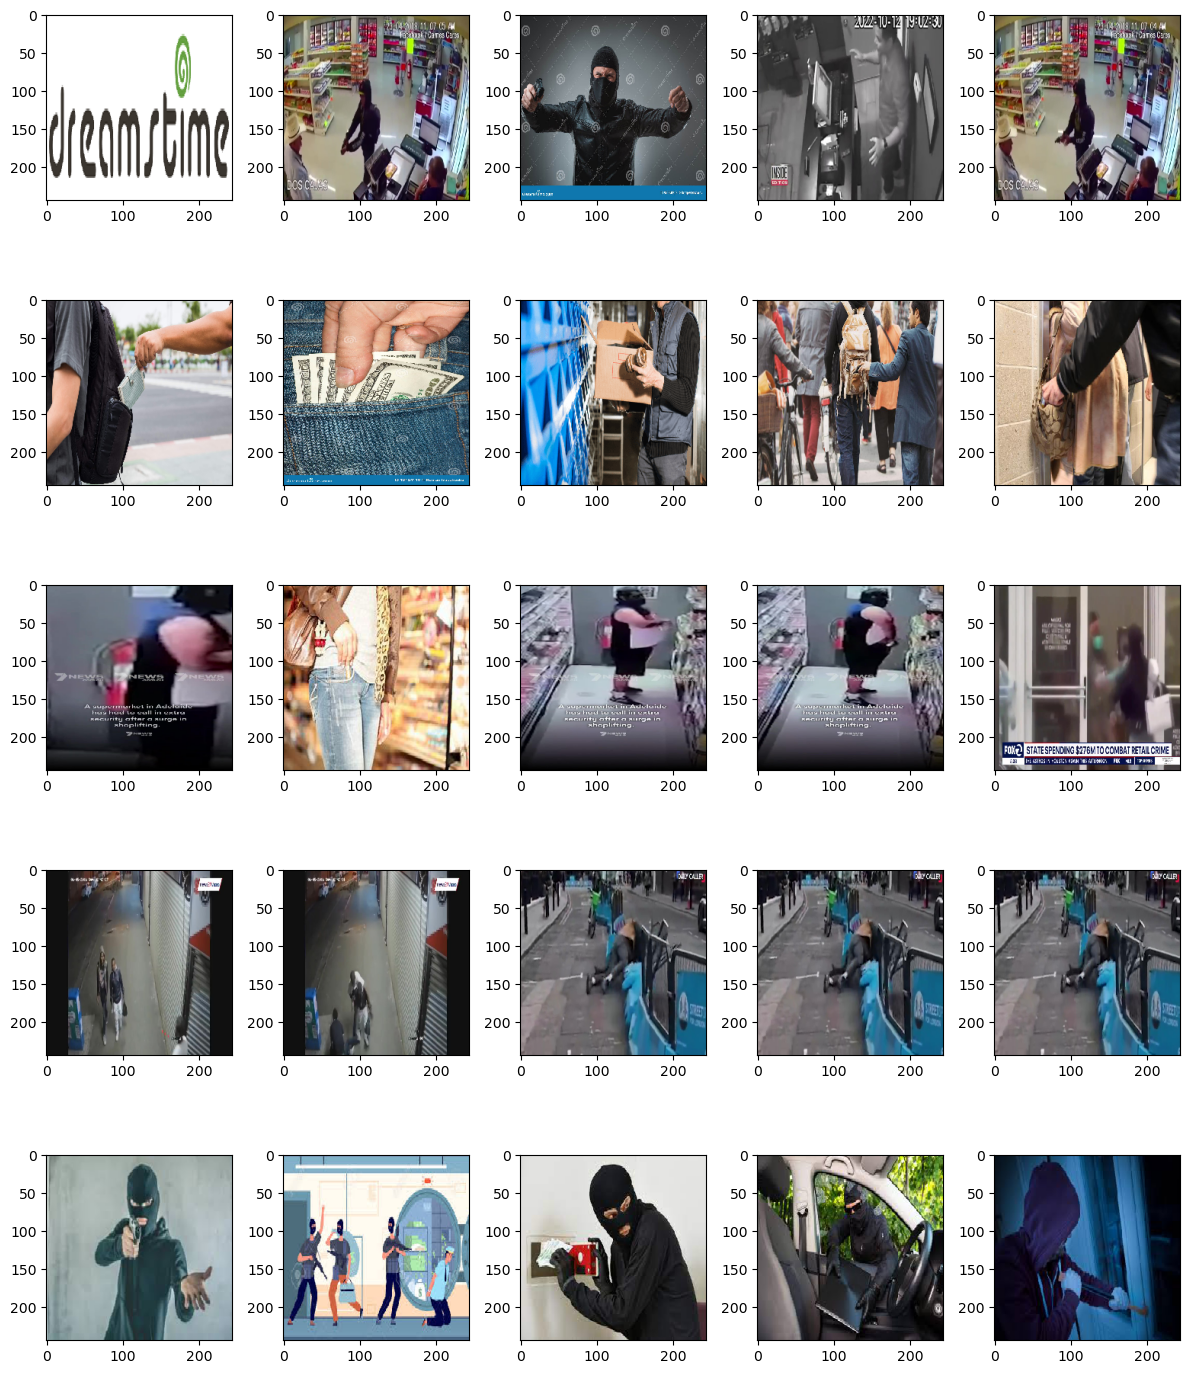

In [ ]:
# display some images for every different expression

import numpy as np
import seaborn as sns
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import os

# size of the image: 48*48 pixels
pic_size = 244

# input path for the images
base_path = "./data/"

plt.figure(0, figsize=(12,20))
cpt = 0

for expression in os.listdir(base_path + "train/"):
    for i in range(1,6):
        cpt = cpt + 1
        plt.subplot(7,5,cpt)
        img = load_img(base_path + "train/" + expression + "/" +os.listdir(base_path + "train/" + expression)[i], target_size=(pic_size, pic_size))
        plt.imshow(img, cmap="gray")

plt.tight_layout()
plt.savefig('plots/data_visualisation.png')
plt.show()


In [2]:
for expression in os.listdir(base_path + "train"):
    print(str(len(os.listdir(base_path + "train/" + expression))) + " " + expression + " images")

1010 gun_theft images
1000 pickpocket images
1000 shoplift images
1054 snatching images
1000 theft images


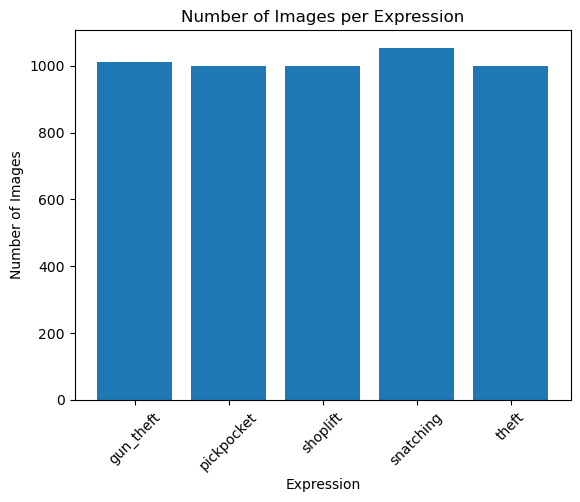

In [19]:
expressions = os.listdir(base_path + "train")

num_images = []
expression_labels = []

for expression in expressions:
    expression_path = os.path.join(base_path, "train", expression)
    num_images.append(len(os.listdir(expression_path)))
    expression_labels.append(expression)

# Create a bar plot
plt.bar(expression_labels, num_images)
plt.xlabel("Expression")
plt.ylabel("Number of Images")
plt.title("Number of Images per Expression")
plt.xticks(rotation=45)
plt.savefig('plots/data_visualisation 2.png')
plt.show()


In [3]:
from keras.preprocessing.image import ImageDataGenerator

# number of images to feed into the NN for every batch
batch_size = 128

datagen_train = ImageDataGenerator()
datagen_validation = ImageDataGenerator()

train_generator = datagen_train.flow_from_directory(base_path + "train",
                                                    target_size=(pic_size,pic_size),
                                                    color_mode="grayscale",
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=True)

validation_generator = datagen_validation.flow_from_directory(base_path + "validation",
                                                    target_size=(pic_size,pic_size),
                                                    color_mode="grayscale",
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=False)

Found 5060 images belonging to 5 classes.
Found 522 images belonging to 5 classes.


In [4]:
from keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D
from keras.models import Model, Sequential
from keras.optimizers import Adam

# number of possible label values
nb_classes = 5

# Initialising the CNN
model = Sequential()

# 1 - Convolution
model.add(Conv2D(64,(3,3), padding='same', input_shape=(244, 244,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd Convolution layer
model.add(Conv2D(128,(5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 4th Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening
model.add(Flatten())

# Fully connected layer 1st layer
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Fully connected layer 2nd layer
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(nb_classes, activation='softmax'))

opt = Adam(learning_rate = 0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

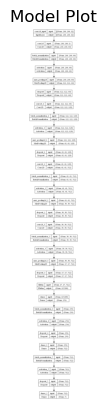

In [21]:
from keras.utils import plot_model

#plot_model(model, to_file='plots/model.png', show_shapes = True)
plot_model(model, to_file='./plots/model_plot.png', show_shapes=True, show_layer_names=True)
# Show the plot.
plt.imshow(plt.imread('plots/model_plot.png'))
plt.axis('off')
plt.title('Model Plot')
plt.show()

In [22]:
#print model sammary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 244, 244, 64)      640       
                                                                 
 batch_normalization (Batch  (None, 244, 244, 64)      256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 244, 244, 64)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 122, 122, 64)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 122, 122, 64)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 122, 122, 128)     2

In [1]:
# number of epochs to train the NN
epochs = 10

from keras.callbacks import ModelCheckpoint

#checkpoint = ModelCheckpoint("./model/model_weights.h5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')
#callbacks_list = [checkpoint]

history = model.fit_generator(generator=train_generator,
                                steps_per_epoch=train_generator.n//train_generator.batch_size,
                                epochs=epochs,
                                validation_data = validation_generator,
                                validation_steps = validation_generator.n//validation_generator.batch_size,
                                #callbacks=callbacks_list
                                )
model.save("./model/model_weights.h5")

NameError: name 'model' is not defined

In [ ]:
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)